In [2]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset, WeightedRandomSampler
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from typing import Tuple
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.preprocessing import *
from python_scripts import plotting

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


### Load cnn and CIFAR10 data

In [3]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/Emilien JEMELEN/Documents/CIFAR/cifar_data", train=False, transform=transform, download=True)

# airplance = 1, not airplane = 0
binarize_labels(full_train_dataset)
binarize_labels(official_test_dataset)

In [4]:
# Combine both datasets
combined_dataset = ConcatDataset([full_train_dataset, official_test_dataset])
# Total combined length
total_length = len(combined_dataset)
# Shuffle and split indices
indices = list(range(total_length))
rd.shuffle(indices)
# Split into train (for cnn training) and test (which will be training+test sets for Selective Prediction module)
train_indices = indices[:20000]
test_indices = indices[20000:]
# Create subsets
new_train_dataset = Subset(combined_dataset, train_indices)
new_test_dataset = Subset(combined_dataset, test_indices)
# get their associated labels from combined_dataset
train_labels = get_subset_labels(new_train_dataset, combined_dataset)
test_labels = get_subset_labels(new_test_dataset, combined_dataset)

# Create test dataloader (which will be training+test sets for Selective Prediction module)
test_loader = DataLoader(new_test_dataset, batch_size=6, shuffle=False)

# Create balanced samplers for training and validation of cnn
train_sampler = get_balanced_sampler(train_labels)
val_sampler = get_balanced_sampler(test_labels)
# Create DataLoaders using balanced samplers
train_loader = DataLoader(new_train_dataset, batch_size=6, sampler=train_sampler)
val_loader = DataLoader(new_test_dataset, batch_size=6, sampler=val_sampler)

In [5]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=20, kernel_size=4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=20, out_channels=32, kernel_size=4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))  # Force feature map to 4x4
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)             # Output shape: [B, 32, 4, 4]
        x = x.view(x.size(0), -1)             # Flatten safely: [B, 512]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model
cnn = SmallCNN().to(device)

In [6]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/Emilien JEMELEN/Documents/SGR/models_weights/cnn_cifar_binary_epoch7.pth", map_location=torch.device('cpu'))
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [7]:
i = iter(test_loader)

In [80]:
batch = next(i)
images, labels = batch
labels

tensor([0, 0, 0, 0, 0, 0])

In [81]:
logits = cnn(images)
F.softmax(logits, dim=1)

tensor([[0.9634, 0.0366],
        [0.7780, 0.2220],
        [0.5442, 0.4558],
        [0.2653, 0.7347],
        [0.8557, 0.1443],
        [0.7822, 0.2178]], grad_fn=<SoftmaxBackward0>)

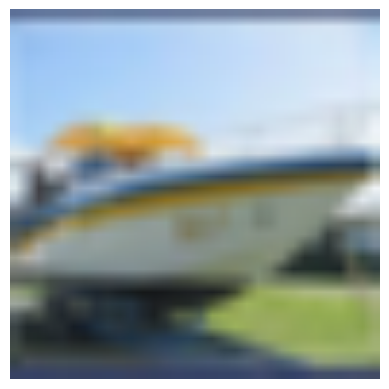

In [82]:
plotting.show_cifar10(images[3])